# Lab: Multiple Linear Regression

---

## 1. Introduction
In the [previous lab](./03_lab--simple_linear_regression.ipynb), we built a Simple Linear Regression model using only one feature. Now we'll take the next step by building a **Multiple Linear Regression** model, which can leverage two or more features to create a more powerful and nuanced prediction.

* **Goal:** To build a model that predicts the CO2 emissions of a car using multiple features, such as engine size and fuel consumption.
* **Data:** We will continue using the Canadian fuel consumption dataset.

---

## 2. Setup and Data Loading

As before, we'll start by importing our essential libraries and loading the dataset.

In [23]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

# Display a sample of the data
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
1012,2014,TOYOTA,YARIS,COMPACT,1.5,4,A4,X,7.9,6.6,7.3,39,168
445,2014,GMC,SAVANA 1500 PASSENGER AWD,VAN - PASSENGER,5.3,8,A4,X,18.3,14.2,16.5,17,380
768,2014,MERCEDES-BENZ,S 550 4MATIC SWB,FULL-SIZE,4.7,8,AS7,Z,14.2,9.4,12.0,24,276
59,2014,AUDI,S5 CABRIOLET,SUBCOMPACT,3.0,6,A7,Z,13.3,9.5,11.6,24,267
264,2014,CHEVROLET,SUBURBAN 4WD,SUV - STANDARD,5.3,8,A6,E,21.5,14.6,18.4,15,294



---

## 3. Feature Selection for Multiple Regression

With multiple regression, choosing the right set of features is crucial. We want features that are highly correlated with our target (`CO2EMISSIONS`) but **not highly correlated with each other**. Including features that are correlated with each other (a problem called **multicollinearity**) can make the model unstable and difficult to interpret.

Let's start by creating a subset of potentially useful numerical features.

In [24]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB','FUELCONSUMPTION_COMB_MPG','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


Now, let's generate a **correlation matrix**. This is a powerful tool that shows the pairwise correlation between all of our selected features. Values close to 1.0 or -1.0 indicate a strong correlation.

In [25]:
# Calculate and display the correlation matrix
correlation_matrix = cdf.corr()
correlation_matrix

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


#### How to Read the Correlation Matrix

1. **Focus on the Target Row (`CO2EMISSIONS`):** Look at the last row. We can see that `ENGINESIZE`, `CYLINDERS`, and the `FUELCONSUMPTION` metrics are all strongly correlated with `CO2EMISSIONS` (values are close to 1.0 or -1.0). This is great! It means they are all potentially good predictors.

2. **Check for Multicollinearity:** Now look at the correlations *between the features**.
    * Notice the correlation between `ENGINESIZE` and `CYLINDERS` is very high (0.93). They essentially carry the same information. Including both would be redundant. We should pick one. Since `ENGINESIZE` has a slightly higher correlation with our target (0.87 vs 0.85), we'll keep `ENGINESIZE`.
    * The three `FUELCONSUMPTION` metrics (`_CITY`, `_HWY`, `_COMB`) are all extremely highly correlated with each other (>0.96). We definitely only need one. `FUELCONSUMPTION_COMB` is a good, balanced choice.
    *   `FUELCONSUMPTION_COMB` and `FUELCONSUMPTION_COMB_MPG` measure the same thing in different units, so their correlation is almost -1.0. We'll choose `FUELCONSUMPTION_COMB` for our model.

#### Visualizing the Correlation Matrix
While the table is useful, a heatmap provides an immediate, visual way to spot strong correlations. We can use the `seaborn` library for this.

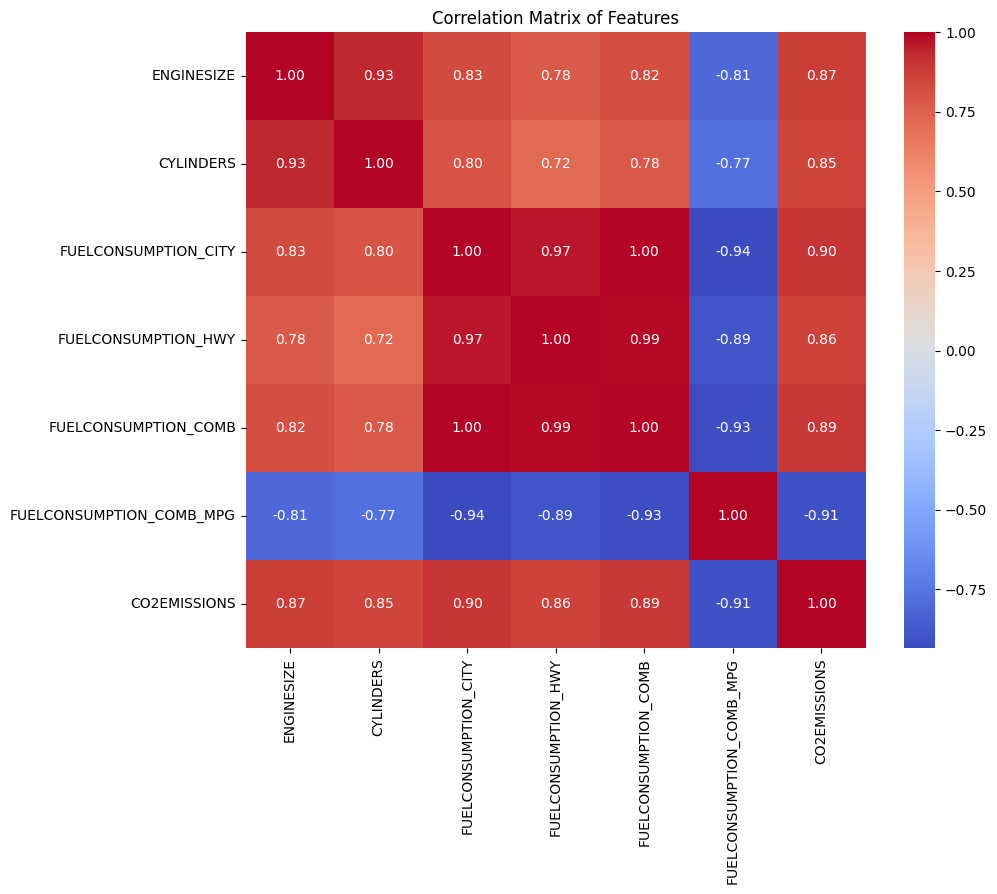

In [26]:
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

*   **Bright red cells** indicate a strong positive correlation (close to +1.0). For example, the box where `ENGINESIZE` and `CYLINDERS` intersect is bright red, confirming they are highly correlated.
*   **Bright blue cells** indicate a strong negative correlation (close to -1.0). For example, `FUELCONSUMPTION_COMB_MPG` is bright blue when crossed with `CO2EMISSIONS`.
*   **Colors closer to white** indicate a weak correlation (close to 0).

This visual confirms our analysis: we should pick one feature from the `ENGINESIZE`/`CYLINDERS` group and one from the fuel consumption group to avoid multicollinearity.

> 📝 **Final Feature Selection:** Based on this analysis, we will build our model using `ENGINESIZE` and `FUELCONSUMPTION_COMB`. They are both strong predictors of the target and are not perfectly correlated with each other.

> ❗️ **Attention:** As a final check, it is best practice to visually confirm that the relationship between these selected features and our target is indeed linear. We already did this in the previous lab for Simple Linear Regression and saw that both features have a strong linear trend with `CO2EMISSIONS`, so we can confidently proceed.

---

## 4. Data Preparation for Modeling

Now that we've selected our features, let's prepare the data for training.

In [27]:
# Define our feature matrix (X) and target vector (y)
X = cdf[["ENGINESIZE", "FUELCONSUMPTION_COMB"]].values
y = cdf["CO2EMISSIONS"].values

We'll split our data into training (80%) and testing (20%) sets. This allows us to train the model on one set and get an unbiased evaluation of its performance on another.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Standardizing the Features

Our features, `ENGINESIZE` (ranges from ~1-8) and `FUELCONSUMPTION_COMB` (ranges from ~5-26), are on different scales. For many machine learning algorithms, this difference in scale can cause the algorithm to give more importance to features with larger values.

**Standardization** is a common technique that rescales the data to have a mean of 0 and a standard deviation of 1. While not strictly necessary for standard OLS Linear Regression, it is a crucial best practice for many other algorithms and helps in interpreting coefficients in regularized models.

> ❗️ **Attention:** We `fit` the scaler **only on the training data** to learn the mean and standard deviation. We then use this *same* fitted scaler to `transform` both the training and testing data. This prevents any information from the test set from "leaking" into our training process.


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---

## 5. Build and Train the Multiple Linear Regression Model

Now we will train our model on the **scaled** training data. The process in Scikit-learn is almost identical to simple linear regression, but now our model will learn a coefficient for each feature.

In [30]:
from sklearn import linear_model

# Create an instance of the LinearRegression object
regr = linear_model.LinearRegression()

# Train the model using our training data
regr.fit(X_train_scaled, y_train)

# Let's look at the parameters the model learned
print(f"Coefficients (for scaled data): {regr.coef_}")
print(f"Intercept: {regr.intercept_:.2f}")

Coefficients (for scaled data): [27.70184245 33.37194998]
Intercept: 257.26


> 📝 **Interpretation of Scaled Coefficients:** These coefficients represent the change in CO2 emissions for a one *standard deviation* increase in the respective feature, which can make it easier to compare feature importance.

---

## 6. Evaluate the Model
Let's see how our model performs on the **scaled** unseen test data.

In [31]:
from sklearn.metrics import r2_score

# Use the trained model to make predictions on the test set
y_pred = regr.predict(X_test_scaled)

# Calculate the R-squared score
print(f"R-squared (R²): {r2_score(y_test, y_pred):.2f}")

R-squared (R²): 0.87


📊 **Result Analysis:** An R² score of **0.87** is a significant improvement over the models we built in the previous lab!
* Simple model with `ENGINESIZE` only: R² = 0.76
* Simple model with `FUELCONSUMPTION_COMB` only: R² = 0.80
* **Multiple model with both features: R² = 0.87** 

By combining the information from two (less correlated) features, we were able to explain 87% of the variability in CO2 emissions, creating a much more accurate model.

### Visualizing the Residuals

A good way to check a regression model's performance is to plot the **residuals** (the difference between the actual and predicted values). In a well-fitting model, the residuals should be randomly scattered around zero, with no obvious pattern.

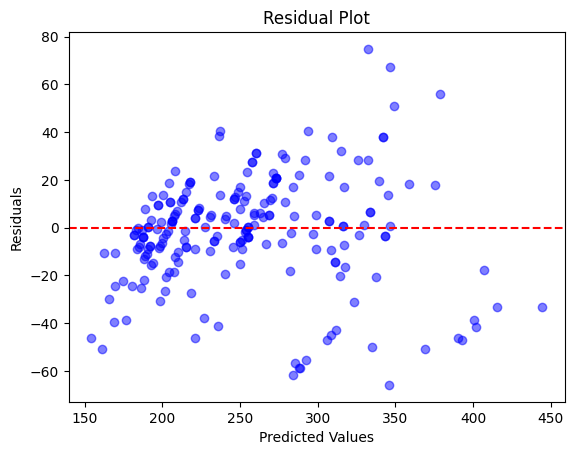

In [32]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.scatter(y_pred, residuals, color="blue", alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

🔍 **Observation:** The residuals are mostly scattered randomly around the zero line, which is a good sign! There isn't a clear U-shape or funnel shape, suggesting our linear model is a reasonable fit for this data.

---

**Next:** [Polynomial Regression Theory](./08_polynomial_regression_theory.md)